# Demo · Retrieving information **and images** from the multimodal ACL index

This notebook queries the `*-nb7-index` built by this repo and shows four things:

1. **Full-text retrieval** of information (text chunks, with figures verbalized inline).
2. **Semantic retrieval** (semantic ranker over the same chunks).
3. **Text → image vector search** — find images with a text prompt via the Azure AI Vision
   image vector space, then **render the extracted images inline**.
4. **Multimodal join** — a text chunk next to the image it verbalizes.

Every query forwards the caller's token in `x-ms-query-source-authorization`, so results are
**ACL-trimmed** to your identity.

In [1]:
import os, base64, io
import requests
from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from IPython.display import display, Image as IPyImage, Markdown

load_dotenv()

SEARCH = os.environ["AZURE_SEARCH_ENDPOINT"].rstrip("/")
API = os.environ.get("AZURE_SEARCH_API_VERSION", "2026-05-01-preview")
INDEX = os.environ.get("RESOURCE_PREFIX", "sharepoint") + "-nb7-index"

_cred = DefaultAzureCredential()
def token():
    return _cred.get_token("https://search.azure.com/.default").token

def search(body, as_user=True):
    t = token()
    headers = {"Authorization": f"Bearer {t}", "Content-Type": "application/json"}
    if as_user:
        # ACL trimming: Search returns only what THIS identity is allowed to see.
        headers["x-ms-query-source-authorization"] = t
    r = requests.post(f"{SEARCH}/indexes/{INDEX}/docs/search?api-version={API}",
                      headers=headers, json=body)
    if not r.ok:
        raise RuntimeError(f"{r.status_code} {r.reason}\n{r.text}")
    return r.json()

print("index:", INDEX)

index: sharepoint-nb7-index


## 1. Full-text retrieval

Search the `content` of the `kind=text` rows. Note the inline `![alt](figures/… "description")`
markdown — that is Content Understanding's **image verbalization** embedded in the chunk text.

In [2]:
QUERY = "sustainability"   # <-- change to anything in your library

res = search({
    "search": QUERY,
    "count": True,
    "top": 5,
    "filter": "kind eq 'text'",
    "select": "sourceFile,page,pageTo,content",
    "queryType": "simple",
})
print(f"matches: {res['@odata.count']}\n" + "=" * 90)
for d in res["value"]:
    print(f"[{d['sourceFile']}]  p.{d.get('page')}-{d.get('pageTo')}")
    print("   " + (d.get("content") or "").strip().replace("\n", " ")[:280])
    print("-" * 90)

matches: 53
[Accelerating-Sustainability-with-AI-2025 (1).pdf]  p.27-28
   ###### Building new markets to deliver the solutions we need  The Microsoft Climate Innovation Fund invests to expand the market supply of climate technologies with the potential to address the industry's carbon, waste, and water footprints. For instance, Microsoft is an investor
------------------------------------------------------------------------------------------
[Accelerating-Sustainability-with-AI-2025 (1).pdf]  p.33-34
   )  40\. Huang, Z. et al. Comprehensive Analysis of Critical Issues in All-Vanadium Redox Flow Battery. ACS Sustain. Chem. Eng. 10, 7786-7810 (2022).  41\. [Bichlien Nguyen, B., and Kwabi, D. Collaborators: Renewable energy storage with Bichlien](https://www.microsoft.com/en-us/re
------------------------------------------------------------------------------------------
[Accelerating-Sustainability-with-AI-2025 (1).pdf]  p.31-32
   ### Empowering entrepreneurs and practitioners to use A

## 2. Semantic retrieval

Same query, but re-ranked by the semantic ranker (`semantic-config`) with extractive captions.

In [3]:
res = search({
    "search": QUERY,
    "top": 3,
    "filter": "kind eq 'text'",
    "queryType": "semantic",
    "semanticConfiguration": "semantic-config",
    "captions": "extractive",
    "select": "sourceFile,page,content",
})
for d in res["value"]:
    caps = d.get("@search.captions") or []
    cap = (caps[0].get("text") if caps else (d.get("content") or ""))
    print(f"[{d['sourceFile']}] p.{d.get('page')}  reranker={d.get('@search.rerankerScore')}")
    print("   " + cap.strip().replace("\n", " ")[:280])
    print("-" * 90)

[Accelerating-Sustainability-with-AI-2025 (1).pdf] p.4  reranker=2.8528528213500977
   ...to unlock a flywheel for accelerating sustainability  ![More sustainable Al operations climate solutions More Al-enabled Accelerating the transition to net zero Greater decarbonization](figures/4.1 "Donut-shaped diagram with three segments surrounding a central circle. PageHea
------------------------------------------------------------------------------------------
[Accelerating-Sustainability-with-AI-2025 (1).pdf] p.3  reranker=2.827331066131592
   Five-point playbook  Play 1 Invest in AI to accelerate sustainability  Play 2 Develop digital and data infrastructure for the inclusive use of AI for sustainability  Play 3  Minimize resource use, expand access to carbon- free electricity, and support local communities  Play 4 Ad
------------------------------------------------------------------------------------------
[Accelerating-Sustainability-with-AI-2025 (1).pdf] p.10  reranker=2.81882381439209


## 3. Text → image vector search + inline rendering

The `imageVector` field is an **Azure AI Vision multimodal** embedding, so we can embed a *text*
prompt into the same space and retrieve the most similar **images**. Each `kind=image` row carries
the picture as base64 `imageData`, which we decode and display inline.

showing 4 image(s) for prompt: 'a chart or diagram about energy'


**Accelerating-Sustainability-with-AI-2025 (1).pdf** — page 1  (113577 bytes)

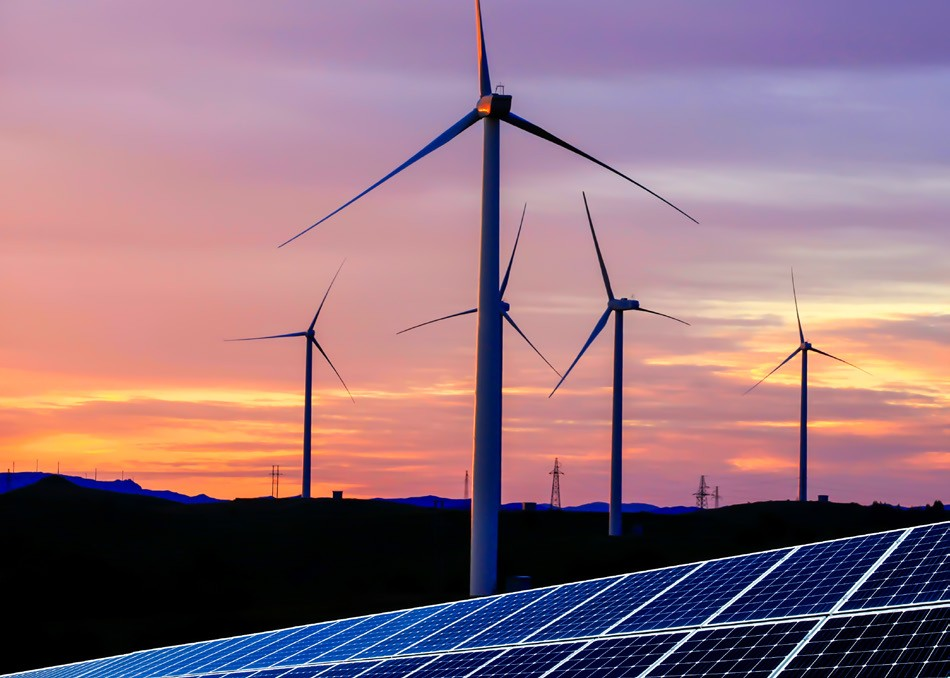

   saved: _out\image_0_p1.jpg


**Accelerating-Sustainability-with-AI-2025 (1).pdf** — page 36  (63175 bytes)

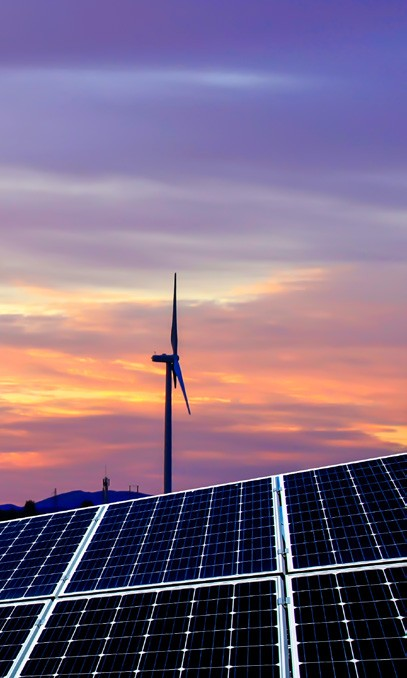

   saved: _out\image_1_p36.jpg


**Accelerating-Sustainability-with-AI-2025 (1).pdf** — page 9  (565306 bytes)

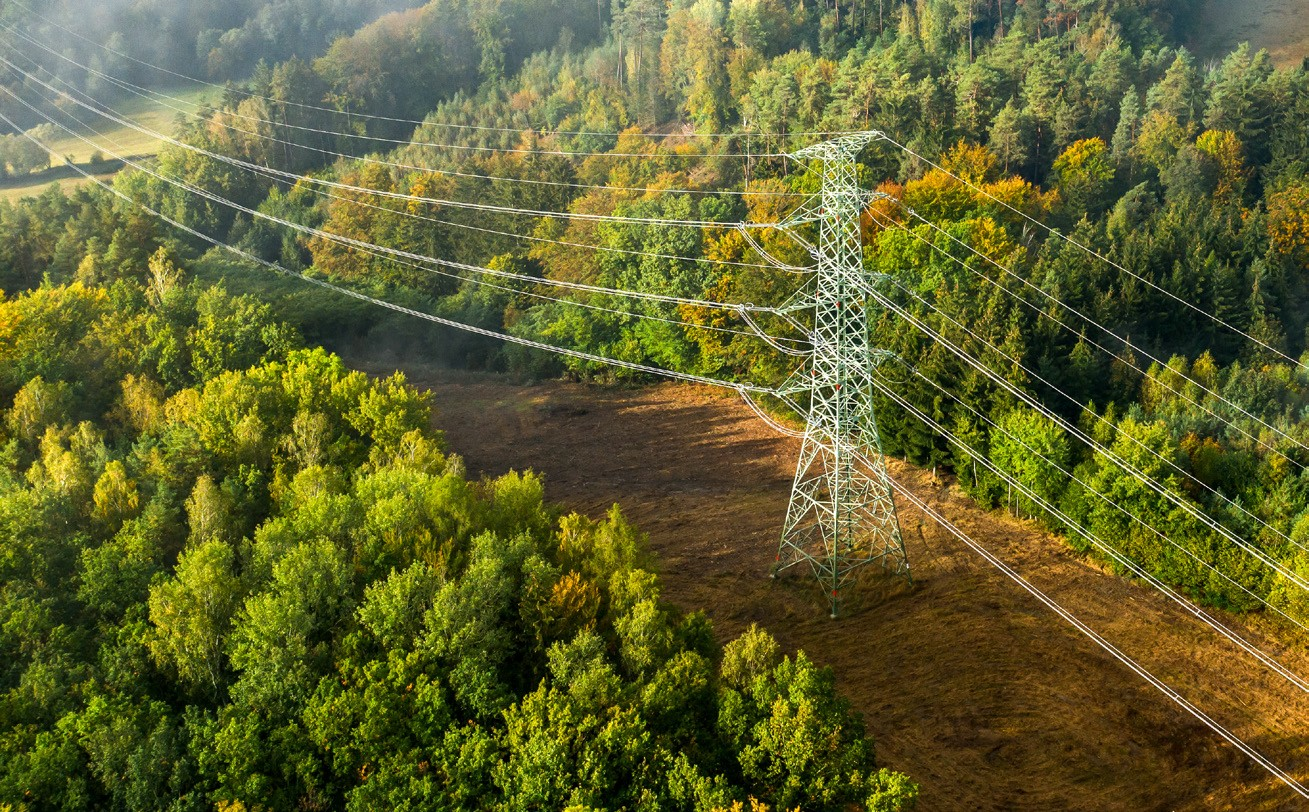

   saved: _out\image_2_p9.jpg


**Accelerating-Sustainability-with-AI-2025 (1).pdf** — page 26  (184334 bytes)

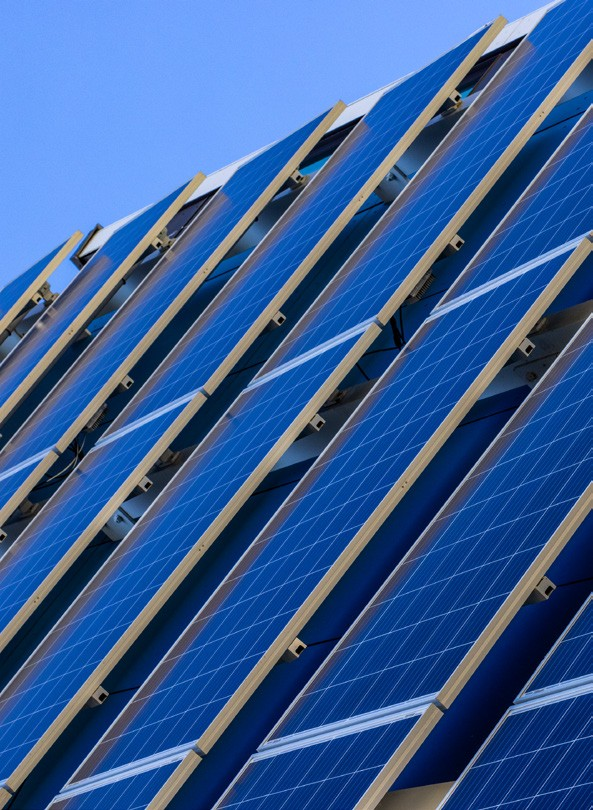

   saved: _out\image_3_p26.jpg


In [4]:
IMAGE_PROMPT = "a chart or diagram about energy"   # <-- text describing the image you want

def decode_image_data(data: str) -> bytes:
    if not data:
        return b""
    if data.startswith("data:"):            # strip optional data-URI prefix
        data = data.split(",", 1)[-1]
    return base64.b64decode(data)

try:
    res = search({
        "search": None,
        "vectorQueries": [{
            "kind": "text",
            "text": IMAGE_PROMPT,
            "fields": "imageVector",
            "k": 4,
        }],
        "filter": "kind eq 'image'",
        "select": "sourceFile,page,imagePath,imageData",
        "top": 4,
    })
    hits = res["value"]
except Exception as e:
    print("Vector search unavailable, falling back to listing image rows:", str(e)[:160])
    res = search({"search": "*", "filter": "kind eq 'image'",
                  "select": "sourceFile,page,imagePath,imageData", "top": 4})
    hits = res["value"]

os.makedirs("_out", exist_ok=True)
print(f"showing {len(hits)} image(s) for prompt: {IMAGE_PROMPT!r}\n" + "=" * 90)
for i, d in enumerate(hits):
    raw = decode_image_data(d.get("imageData"))
    display(Markdown(f"**{d.get('sourceFile')}** — page {d.get('page')}  ({len(raw)} bytes)"))
    if raw:
        display(IPyImage(data=raw))
        out = os.path.join("_out", f"image_{i}_p{d.get('page')}.jpg")
        with open(out, "wb") as f:
            f.write(raw)
        print("   saved:", out)

## 4. Multimodal join — a chunk and the figure it describes

Pick a text chunk that inlines a verbalized figure, then show the extracted image from the **same
document and page**. This is the pairing that makes the index "multimodal": retrievable text that
*describes* the picture, plus the picture itself.

### Text chunk — Accelerating-Sustainability-with-AI-2025 (1).pdf p.18

![INNOVATION SPOTLIGHT 18,000 Today, 18,000 researchers and organizations currently rely on biodiversity and ecosystem monitoring data. SPARROW Filling gaps in biodiversity data Solar-Powered Acoustic and Remote Recording Observation Watch (SPARROW) is an innovative new AI-powered biodiversity monitoring tool developed by Microsoft's Al for Good lab. Its advanced solar-powered sensors record camer

### Extracted image — same document, page 18

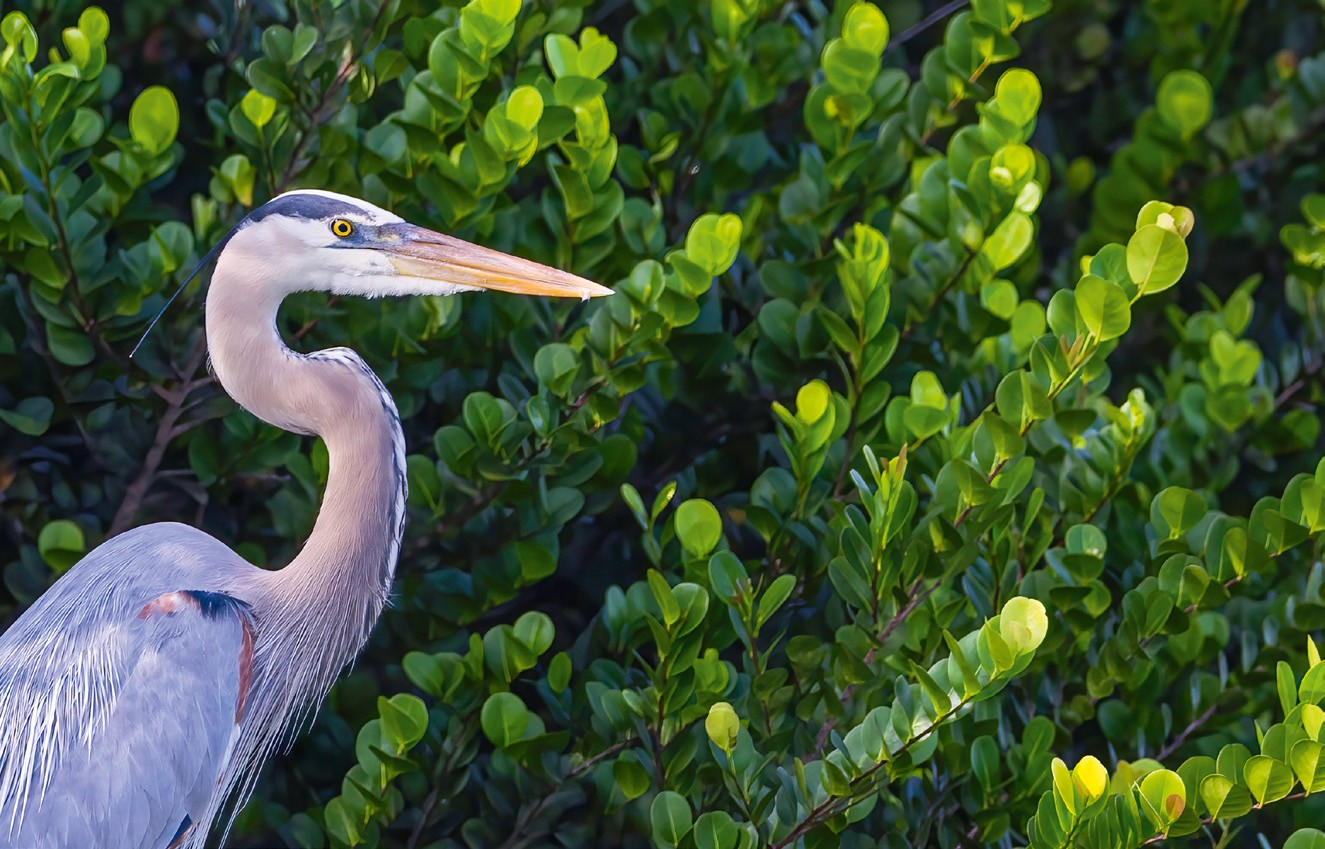

In [5]:
# find a text chunk that contains an inlined figure verbalization
text_rows = search({
    "search": "*", "filter": "kind eq 'text'", "top": 1000,
    "select": "sourceFile,page,content",
})["value"]
verbalized = next((d for d in text_rows if "![" in (d.get("content") or "")), None)

if not verbalized:
    print("No inlined figure verbalization found in the text rows.")
else:
    c = verbalized["content"]
    i = c.find("![")
    display(Markdown(f"### Text chunk — {verbalized['sourceFile']} p.{verbalized.get('page')}"))
    display(Markdown(c[i:i + 400]))

    # fetch an image from the same file + page
    sf = verbalized["sourceFile"].replace("'", "''")
    pg = verbalized.get("page")
    flt = f"kind eq 'image' and sourceFile eq '{sf}'" + (f" and page eq {pg}" if pg is not None else "")
    imgs = search({"search": "*", "filter": flt,
                   "select": "sourceFile,page,imageData", "top": 1})["value"]
    if imgs:
        raw = decode_image_data(imgs[0].get("imageData"))
        display(Markdown(f"### Extracted image — same document, page {imgs[0].get('page')}"))
        if raw:
            display(IPyImage(data=raw))
    else:
        print("No extracted image on that exact page; try another chunk.")